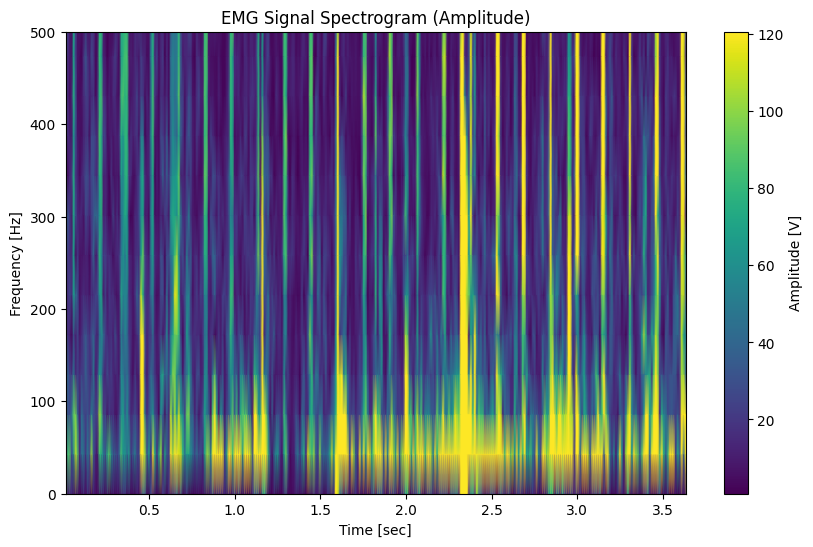

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# ======= USER SETTINGS =======
filename = "./data/Spontanaktivität/filtered_BA0803901_segment_1.wav"  # Path to your EMG WAV file

# ======= LOAD WAV FILE =======
fs, emg_signal = wavfile.read(filename)

# If stereo, convert to mono
if len(emg_signal.shape) > 1:
    emg_signal = emg_signal[:, 0]

# Convert to float and normalize if needed
emg_signal = emg_signal.astype(float)

# ======= COMPUTE SPECTROGRAM =======
frequencies, times, Sxx = signal.spectrogram(
    emg_signal, fs, nperseg=256, noverlap=128, scaling='spectrum', mode='psd'
)

# Convert power to amplitude in volts
Sxx_volts = np.sqrt(Sxx)  # since power = V^2 / R, ignoring R

# Optional: clip extremes for visualization
vmin = np.percentile(Sxx_volts, 5)
vmax = np.percentile(Sxx_volts, 99)

# ======= PLOT =======
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, Sxx_volts, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('EMG Signal Spectrogram (Amplitude)')
plt.colorbar(label='Amplitude')
plt.ylim([0, 500])  # typical EMG frequency range
plt.show()